<a href="https://colab.research.google.com/github/CarlosM2002/MineriadeDatos/blob/main/Proyecto/Proyecto_(DM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**World University Rankings - 2023**

![300 años de la UCV](https://rank.uva.es/wp-content/uploads/2019/02/the-850x550-e1550482456519.png)

Alumnos:
* Marchena Ana 28309145
* Monsalve Carlos 29551025
* Peréz Juan 21407463

# **Preprocesamiento de Datos**

Para proceder a realizar el análisis de preprocesamiento de nuestro dataset elegido (https://www.kaggle.com/datasets/alitaqi000/world-university-rankings-2023), en un inicio (por medio de la libreria Pandas de python) tendremos que importar nuestro archivo CSV ubicado en drive mediante un URL.

In [1]:
import pandas as pd
import numpy as np

url = f'https://docs.google.com/spreadsheets/d/1OJn2ORGDtXKzNE1YrhxWycvaX8rB1VOuYi5G-xbprSI/export?format=csv'
df = pd.read_csv(url)
print(df.shape)
df.head()

(2341, 13)


,University Rank,Name of University,Location,No of student,No of student per staff,International Student,Female:Male Ratio,OverAll Score,Teaching Score,Research Score,Citations Score,Industry Income Score,International Outlook Score
0,1,University of Oxford,United Kingdom,"20,965",10.6,42%,48 : 52,96.4,92.3,99.7,99.0,74.9,96.2
1,2,Harvard University,United States,"21,887",9.6,25%,50 : 50,95.2,94.8,99.0,99.3,49.5,80.5
2,3,University of Cambridge,United Kingdom,"20,185",11.3,39%,47 : 53,94.8,90.9,99.5,97.0,54.2,95.8
3,3,Stanford University,United States,"16,164",7.1,24%,46 : 54,94.8,94.2,96.7,99.8,65.0,79.8
4,5,Massachusetts Institute of Technology,United States,"11,415",8.2,33%,40 : 60,94.2,90.7,93.6,99.8,90.9,89.3


Una vez cargado el dataset decidimos inspeccionar el mismo mas a fondo mediante la herramienta visual de excel, mediante esta pudimos identificar diversos problemas funcionales y de consistencia que podrian afectar el procesamiento y análisis posterior de los datos. Esta revisión preliminar nos permitió detectar múltiples irregularidades que requerían tratamiento antes de aplicar cualquier técnica de modelado.

Entre los principales problemas encontrados se observó una inconsistencia en la columna "University Rank", ya que a partir de ciertas observaciones los valores dejan de ser numéricos individuales y pasan a representarse como rangos. Asimismo, aparece el valor "Reporter", que puede generar dificultades al momento de realizar análisis cuantitativos. De igual manera, en la columna "Name of University" se detectaron registros con valores NaN; si bien algunas de estas observaciones contienen información en otras columnas, el nombre de la universidad es un identificador esencial que no puede inferirse a partir de los demás datos, por lo que su ausencia representa un problema estructural.

Por otra parte, en la columna correspondiente a la ubicación de la universidad también se identificaron campos vacíos, los cuales podrían afectar análisis comparativos por país o región si no se tratan adecuadamente. En conjunto, estas inconsistencias evidenciaron la necesidad de aplicar procesos de limpieza y transformación para garantizar la calidad, coherencia y confiabilidad del dataset antes de continuar con las siguientes fases del proyecto.

1. Como primera medida a tomar para organizar nuestro conjunto de datos hemos comenzando el análisis de los mismos celda por celda de izquierda a derecha, encontrandonos primero con una inconsistencia en el apartado del rango de las universidades, ya que tiene valores muy variados yendo desde símbolos, números enteros y rangos. Esta falta de uniformidad puede impedir realizar cualquier análisis cuantitativo y por ello la solución aplicada consistió en un proceso estandarización donde se unificaron todos los datos faltantes e irrelevantes bajo la etiqueta Unknown, y se transformaron los rangos numéricos extrayendo su límite inferior para definir un rango unico.

In [2]:
def fix_rank(rank):
    val = str(rank).strip()
    if val.lower() == 'reporter' or val == '-' or val == 'nan' or val == '':
        return 'Unknown'

    if '-' in val:
        return val.split('-')[0].strip()
    if '–' in val:
        return val.split('–')[0].strip()
    return val

df['University Rank'] = df['University Rank'].apply(fix_rank)
print(df)

     University Rank                     Name of University        Location  \
0                  1                   University of Oxford  United Kingdom   
1                  2                     Harvard University   United States   
2                  3                University of Cambridge  United Kingdom   
3                  3                    Stanford University   United States   
4                  5  Massachusetts Institute of Technology   United States   
...              ...                                    ...             ...   
2336         Unknown     University of the West of Scotland             NaN   
2337         Unknown                  University of Windsor             NaN   
2338         Unknown            University of Wolverhampton             NaN   
2339         Unknown                University of Wuppertal             NaN   
2340         Unknown    Xi’an Jiaotong-Liverpool University             NaN   

     No of student  No of student per staff Interna

2. Asimismo siguiendo con la evaluacion se denoto que casi al final del archivo una gran cantidad de registros presentaban una falta de datos esenciales como el nombre de la universidad a evaluar, por lo mismo se definio que era esencial que aquellas celdas que no tienen un identificador claro (Name of University) fueran filtradas.

In [3]:
df.dropna(subset=['Name of University'], inplace=True)
print(df)

     University Rank                     Name of University        Location  \
0                  1                   University of Oxford  United Kingdom   
1                  2                     Harvard University   United States   
2                  3                University of Cambridge  United Kingdom   
3                  3                    Stanford University   United States   
4                  5  Massachusetts Institute of Technology   United States   
...              ...                                    ...             ...   
2336         Unknown     University of the West of Scotland             NaN   
2337         Unknown                  University of Windsor             NaN   
2338         Unknown            University of Wolverhampton             NaN   
2339         Unknown                University of Wuppertal             NaN   
2340         Unknown    Xi’an Jiaotong-Liverpool University             NaN   

     No of student  No of student per staff Interna

3. Siguiendo con la actividad observamos que hay muchos valores vacios o nulos dentro de la seccion location, por lo mismo para facilitar los futuros analisis comparativos por ubicación de las universidades se decidio reemplazar los datos nulos por Unknown, estandarizando las columnas de ubicación.

In [4]:
df['Location'] = df['Location'].fillna('Unknown')
print(df)

     University Rank                     Name of University        Location  \
0                  1                   University of Oxford  United Kingdom   
1                  2                     Harvard University   United States   
2                  3                University of Cambridge  United Kingdom   
3                  3                    Stanford University   United States   
4                  5  Massachusetts Institute of Technology   United States   
...              ...                                    ...             ...   
2336         Unknown     University of the West of Scotland         Unknown   
2337         Unknown                  University of Windsor         Unknown   
2338         Unknown            University of Wolverhampton         Unknown   
2339         Unknown                University of Wuppertal         Unknown   
2340         Unknown    Xi’an Jiaotong-Liverpool University         Unknown   

     No of student  No of student per staff Interna

4. En la variable No of student se detectó un problema con el tipo de dato, ya que algunas cantidades estaban almacenadas como texto y no como números enteros. Para corregir esto, primero se realizó una transformación para convertir todos los valores a enteros. Posteriormente, se identificaron registros con números de estudiantes muy bajos en comparación con otras universidades, lo que indicaba posibles valores anómalos. Para solucionar esto, se decidió calcular el promedio de estudiantes por país, de manera que las observaciones con valores atípicos pudieran ser reemplazadas por un valor más representativo dentro de su mismo país, conservando así la coherencia de los datos.

In [5]:
df['No of student'] = (df['No of student'].astype(str).str.replace(',', ''))
df['No of student'] = pd.to_numeric(df['No of student'], errors='coerce').fillna(0).astype(int)
print(df)

     University Rank                     Name of University        Location  \
0                  1                   University of Oxford  United Kingdom   
1                  2                     Harvard University   United States   
2                  3                University of Cambridge  United Kingdom   
3                  3                    Stanford University   United States   
4                  5  Massachusetts Institute of Technology   United States   
...              ...                                    ...             ...   
2336         Unknown     University of the West of Scotland         Unknown   
2337         Unknown                  University of Windsor         Unknown   
2338         Unknown            University of Wolverhampton         Unknown   
2339         Unknown                University of Wuppertal         Unknown   
2340         Unknown    Xi’an Jiaotong-Liverpool University         Unknown   

      No of student  No of student per staff Intern

In [6]:
num = 1000
valid_df = df[df['No of student'] >= num]
avg_students_by_location = valid_df.groupby('Location')['No of student'].mean()

def replace_with_avg(row):
    if row['No of student'] < num:
        if row['Location'] != 'Unknown' and row['Location'] in avg_students_by_location:
            return avg_students_by_location[row['Location']]
        else:
            return row['No of student']

    return row['No of student']

df['No of student'] = df.apply(replace_with_avg, axis=1)
print(df['No of student'])

0       20965.0
1       21887.0
2       20185.0
3       16164.0
4       11415.0
         ...   
2336        0.0
2337        0.0
2338        0.0
2339        0.0
2340        0.0
Name: No of student, Length: 2233, dtype: float64


5. Por otra parte el conjunto de porcentajes de estudiantes masculinos y femeninos se encontraba en una misma columna por lo tanto ambos datos se perdian al estar juntos y eran poco útilos de esta forma, por ello se decidio a separarlos en dos partes para así tener valores únicos por cada uno.

In [7]:
def split_gender(ratio, pos):
    if pd.isna(ratio) or ':' not in str(ratio):
        return "Unknown"
    return str(ratio).split(':')[pos].strip()

df['Female_Percentage'] = df['Female:Male Ratio'].apply(lambda x: split_gender(x, 0))
df['Male_Percentage'] = df['Female:Male Ratio'].apply(lambda x: split_gender(x, 1))
df.drop('Female:Male Ratio', axis=1, inplace=True)
df.head()

,University Rank,Name of University,Location,No of student,No of student per staff,International Student,OverAll Score,Teaching Score,Research Score,Citations Score,Industry Income Score,International Outlook Score,Female_Percentage,Male_Percentage
0,1,University of Oxford,United Kingdom,20965.0,10.6,42%,96.4,92.3,99.7,99.0,74.9,96.2,48,52
1,2,Harvard University,United States,21887.0,9.6,25%,95.2,94.8,99.0,99.3,49.5,80.5,50,50
2,3,University of Cambridge,United Kingdom,20185.0,11.3,39%,94.8,90.9,99.5,97.0,54.2,95.8,47,53
3,3,Stanford University,United States,16164.0,7.1,24%,94.8,94.2,96.7,99.8,65.0,79.8,46,54
4,5,Massachusetts Institute of Technology,United States,11415.0,8.2,33%,94.2,90.7,93.6,99.8,90.9,89.3,40,60


6. Por ultimo podemos notar igualmente que existe una inconsistencia en el puntaje global de las universidades ya que pasan de un número entero a una serie de rangos, por lo mismo se decidio transformar el rango en el promedio del mismo para obtener una variable representativa.

In [8]:
def parse_overall(score):
    if '–' in str(score):
        low, high = str(score).split('–')
        return (float(low) + float(high)) / 2
    return pd.to_numeric(score, errors='coerce')

df['OverAll Score'] = df['OverAll Score'].apply(parse_overall)
df.head()

,University Rank,Name of University,Location,No of student,No of student per staff,International Student,OverAll Score,Teaching Score,Research Score,Citations Score,Industry Income Score,International Outlook Score,Female_Percentage,Male_Percentage
0,1,University of Oxford,United Kingdom,20965.0,10.6,42%,96.4,92.3,99.7,99.0,74.9,96.2,48,52
1,2,Harvard University,United States,21887.0,9.6,25%,95.2,94.8,99.0,99.3,49.5,80.5,50,50
2,3,University of Cambridge,United Kingdom,20185.0,11.3,39%,94.8,90.9,99.5,97.0,54.2,95.8,47,53
3,3,Stanford University,United States,16164.0,7.1,24%,94.8,94.2,96.7,99.8,65.0,79.8,46,54
4,5,Massachusetts Institute of Technology,United States,11415.0,8.2,33%,94.2,90.7,93.6,99.8,90.9,89.3,40,60


# **Análisis exploratorio de los datos**

1. Para comprender el comportamiento de los datos, realizaremos un análisis exploratorio detallado. Utilizaremos herramientas de visualización, comenzando con el histograma, para interpretar la distribución de las variables y establecer el contexto necesario para las fases posteriores.

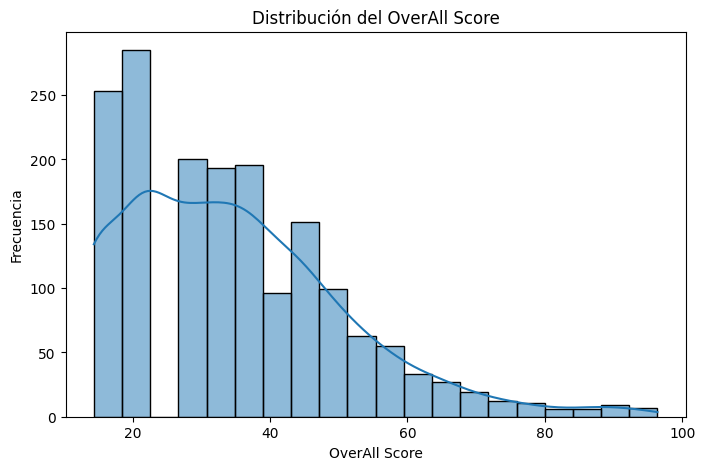

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['OverAll Score'], bins=20, kde=True)

plt.title('Distribución del OverAll Score')
plt.xlabel('OverAll Score')
plt.ylabel('Frecuencia')

plt.show()

- Al analizar el histograma de la variable "OverAll Score" se observauna distribución con un marcado sesgo a la derecha, donde vemos que la mayor concentración de universidades se agrupa en los rangos de puntaje bajos y medios, mientras que la frecuencia disminuye drásticamente hacia los valores altos. Esta cola prolongada hacia la derecha nos indica entonces que solo un grupo reducido de instituciones logra alcanzar puntajes de excelencia superiores a 80.

2. Otra herramienta para afianzar lo que vemos en el histograma, con la misma variable, es el Boxplot, con este estudio podemos observar de mejor manera como estan distribuidas estas universidades.

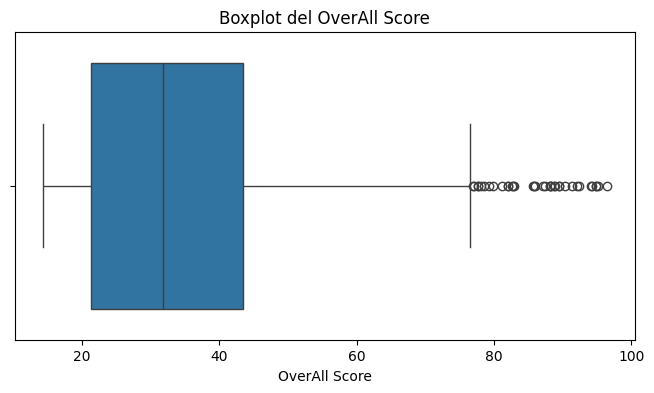

In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['OverAll Score'])

plt.title('Boxplot del OverAll Score')
plt.xlabel('OverAll Score')

plt.show()

Primero que nada, podemos observar que, la línea dentro de la caja parece estar alrededor de los valores (30,35), lo cual significa que:

- El 50% de las universidades tiene un puntaje menor a ese valor.
- Esto confirma que la mayoría no está en niveles altos.

Tambien observamos que el 50% central está entre (22,45), la caja indica dónde está el grueso de los datos, esto significa que:

- La mayor concentración de universidades está en un rango medio-bajo.

- No hay mucha dispersión dentro del grupo principal.


Por ultimo podemos observar muchos puntos a la derecha, en el rango (75,95), y esto significa:

- Existen universidades con desempeño extremadamente alto.
- Son casos poco frecuentes.

3. Otra herramienta importate para observar como se relacionan estas variables es el Heatmapo, sin embargo esta misma solo admite datos numéricos, por lo cual filtraremos primero el conjunto de datos para trabajar únicamente con las columnas cuantitativas (numeric_cols). Esto nos permitirá identificar visualmente qué variables están más conectadas entre sí.

In [11]:
numeric_cols = [
    'OverAll Score',
    'Teaching Score',
    'Research Score',
    'Citations Score',
    'Industry Income Score',
    'International Outlook Score',
    'International Student',
    'No of student',
    'No of student per staff'
]

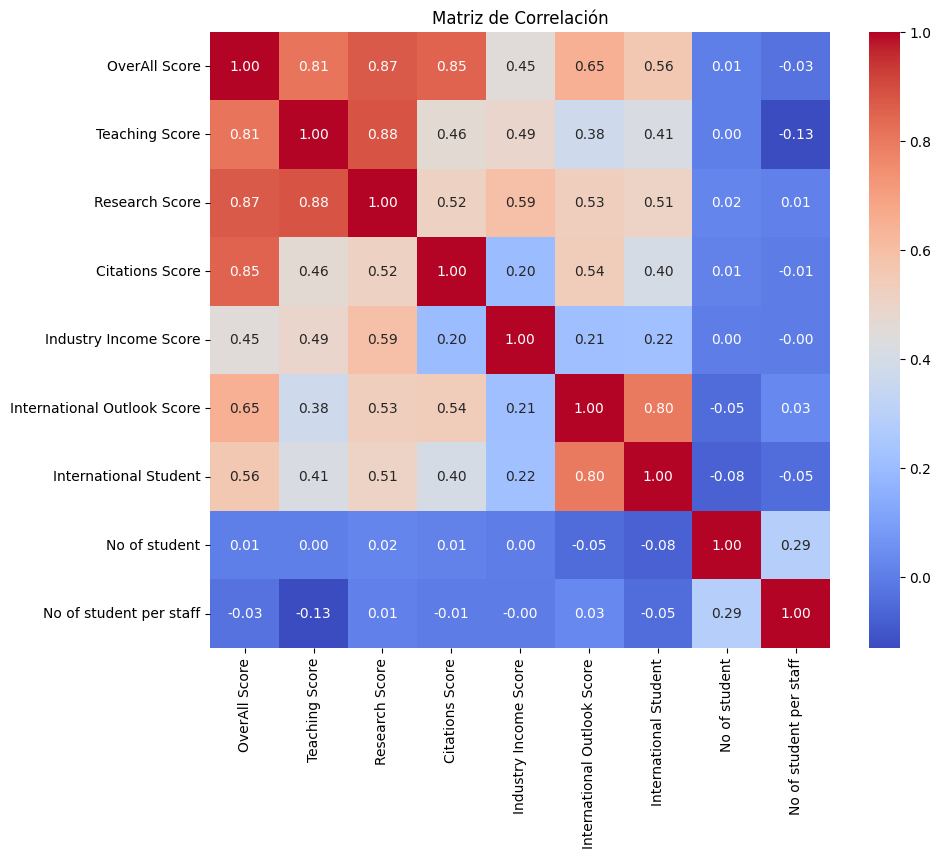

In [12]:
df['International Student'] = df['International Student'].str.replace('%', '', regex=False)
df['International Student'] = pd.to_numeric(df['International Student'], errors='coerce').fillna(0).astype(float)
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Matriz de Correlación")
plt.show()

3.1 Ahora poodremos observar un patrón claro en el que "OverAll Score" está fuertemente relacionado con las variables:
- Research Score (0.87)
- Citations Score (0.85)
- Teaching Score (0.81)

El patrón que observamos son estos indicadores "académicos tradicionales", los cuales son especialmente investigación y citaciones. Esto indica que el ranking prioriza el desempeño científico.

Por su contraparte el tamaño de "matrícula" influye muy poco (esta muy poco relacionado) con es score de la universidades 0.01 y -0.03 para No of student y No of student per staff respectivamente.

4. Ahora para observar gráficamente la correlación entre Research y OverAll Score podemos usar el scatterplot, donde el gráfico nos mostrara que existe una fuerte relación positiva entre el puntaje de investigación y el puntaje global.

- Esto significa que las universidades con mayor desempeño en investigación tienden a obtener mejores posiciones en el ranking general.

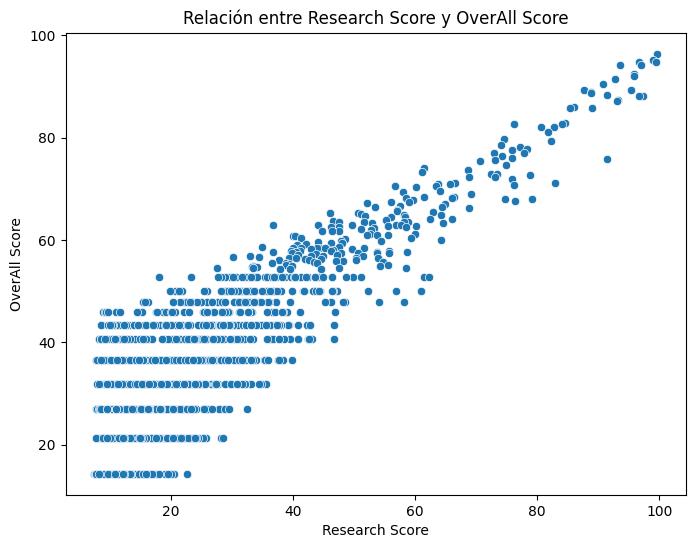

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Research Score'],
    y=df['OverAll Score']
)

plt.title('Relación entre Research Score y OverAll Score')
plt.xlabel('Research Score')
plt.ylabel('OverAll Score')

plt.show()

4.1 Podemos agregar a este mismo gráfico una linea de regresión, donde se puede observar claramente que tiene pendiente positiva.

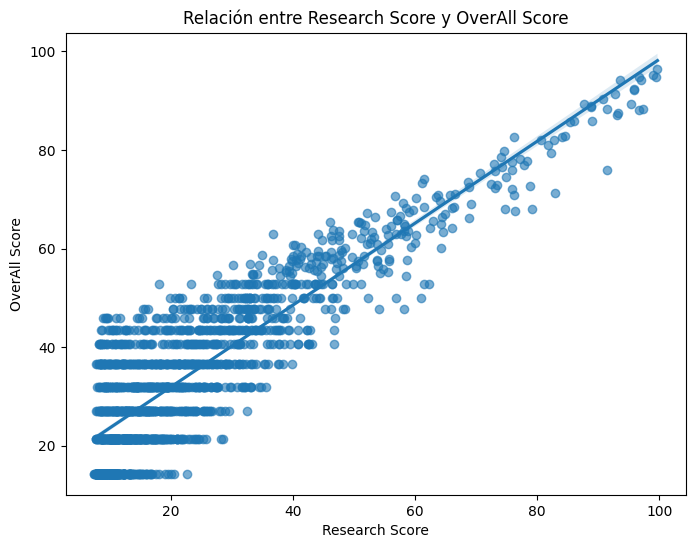

In [14]:
plt.figure(figsize=(8,6))

sns.regplot(
    x=df['Research Score'],
    y=df['OverAll Score'],
    scatter_kws={'alpha':0.6}
)

plt.title('Relación entre Research Score y OverAll Score')
plt.xlabel('Research Score')
plt.ylabel('OverAll Score')

plt.show()

5. En el heatmap a pesar de que las variables con mayor correlación eran Research, Citiation y Teaching. También existen variables que a pesar de no tener una correalacion tan alta, son significativas, una de ellas es la variable de "International Student", es decir, la internacionalización. Si bien no es una prioridad al momento de puntuar, también aporta valor de forma significativa.

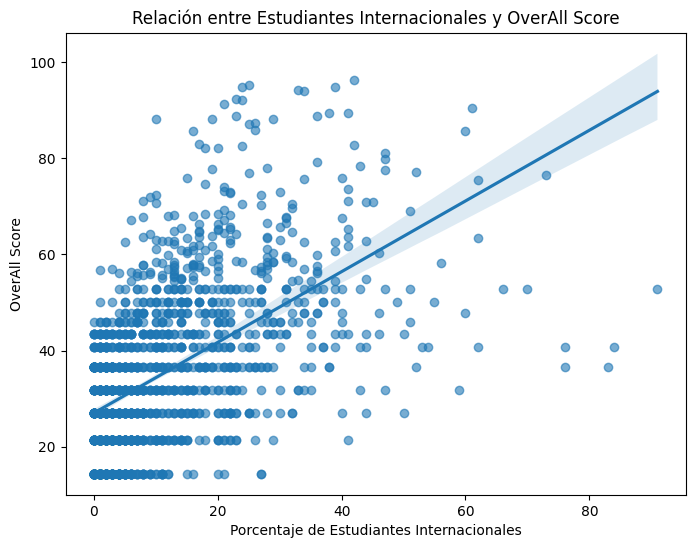

In [15]:
plt.figure(figsize=(8,6))

sns.regplot(
    x=df['International Student'],
    y=df['OverAll Score'],
    scatter_kws={'alpha':0.6}
)

plt.title('Relación entre Estudiantes Internacionales y OverAll Score')
plt.xlabel('Porcentaje de Estudiantes Internacionales')
plt.ylabel('OverAll Score')

plt.show()

- En el gráfico "international student vs overall", podemos observar también una línea de regresión con pendiente positiva, pero, los puntos no están cerca de dicha línea, esto sígnifica que aunque la tendencia es clara no solo el Research Score es el único factor si no que existen otras variables que también influyen en el ranking.

6. Otro dato relevante es la baja proporción de estudiantes internacionales en la mayoría de las instituciones. El histograma refleja esta tendencia con un pico pronunciado cerca del valor 0, lo que indica que para la gran mayoría de las universidades, la internacionalización de su alumnado es mínima o nula.

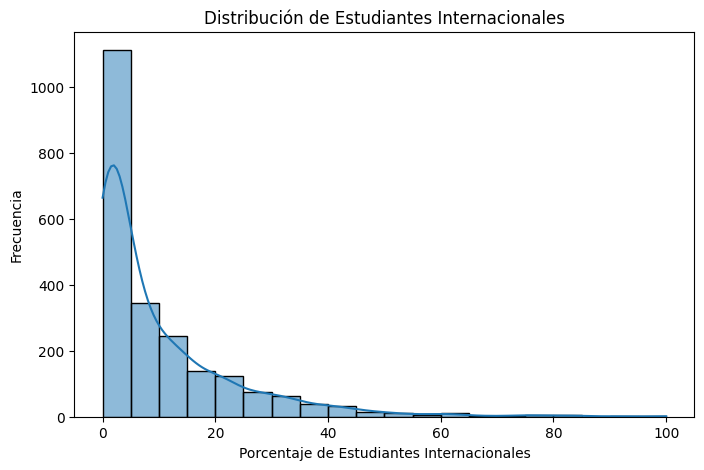

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['International Student'], bins=20, kde=True)

plt.title('Distribución de Estudiantes Internacionales')
plt.xlabel('Porcentaje de Estudiantes Internacionales')
plt.ylabel('Frecuencia')

plt.show()

7. Como un dato interesante, podemos observar que, Singapur destaca como el país con el mejor OverAll Score promedio, alcanzando una media cercana a los 78 puntos. Este desempeño es notablemente superior al de otros países líderes, superando por casi 10 puntos el promedio obtenido por los Países Bajos.

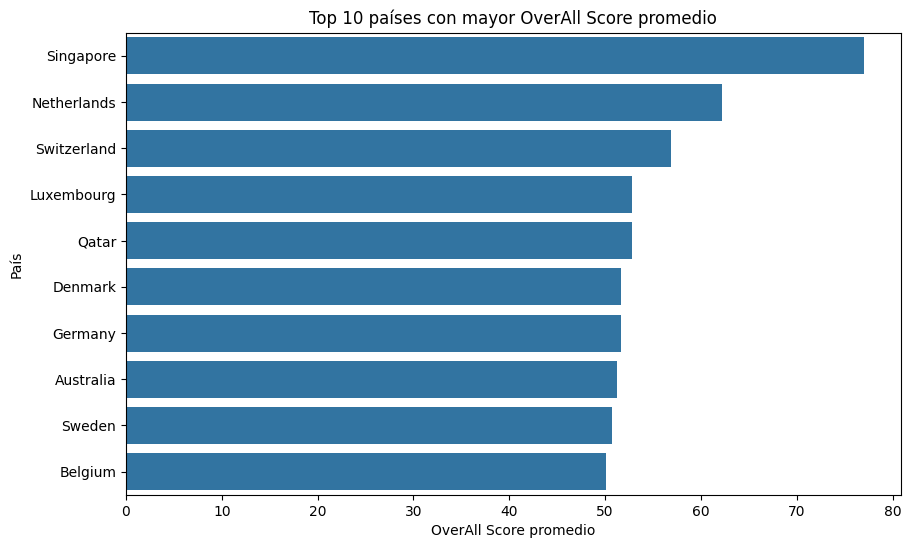

In [17]:
top_countries = (
    df.groupby('Location')['OverAll Score']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title('Top 10 países con mayor OverAll Score promedio')
plt.xlabel('OverAll Score promedio')
plt.ylabel('País')

plt.show()

8. Por ultimo, al observar el gráfico, es evidente una predominancia masculina en la mayoría de estas exitosas universidades: el MIT presenta la mayor brecha de género (cerca de 60% hombres y 40% mujeres), Oxford, Cambridge y Stanford muestran mayorías masculinas más moderadas, y la gran excepción es la Universidad de Harvard, que destaca por ser la única en alcanzar un distribución de género perfecta con un 50% exacto para cada uno.

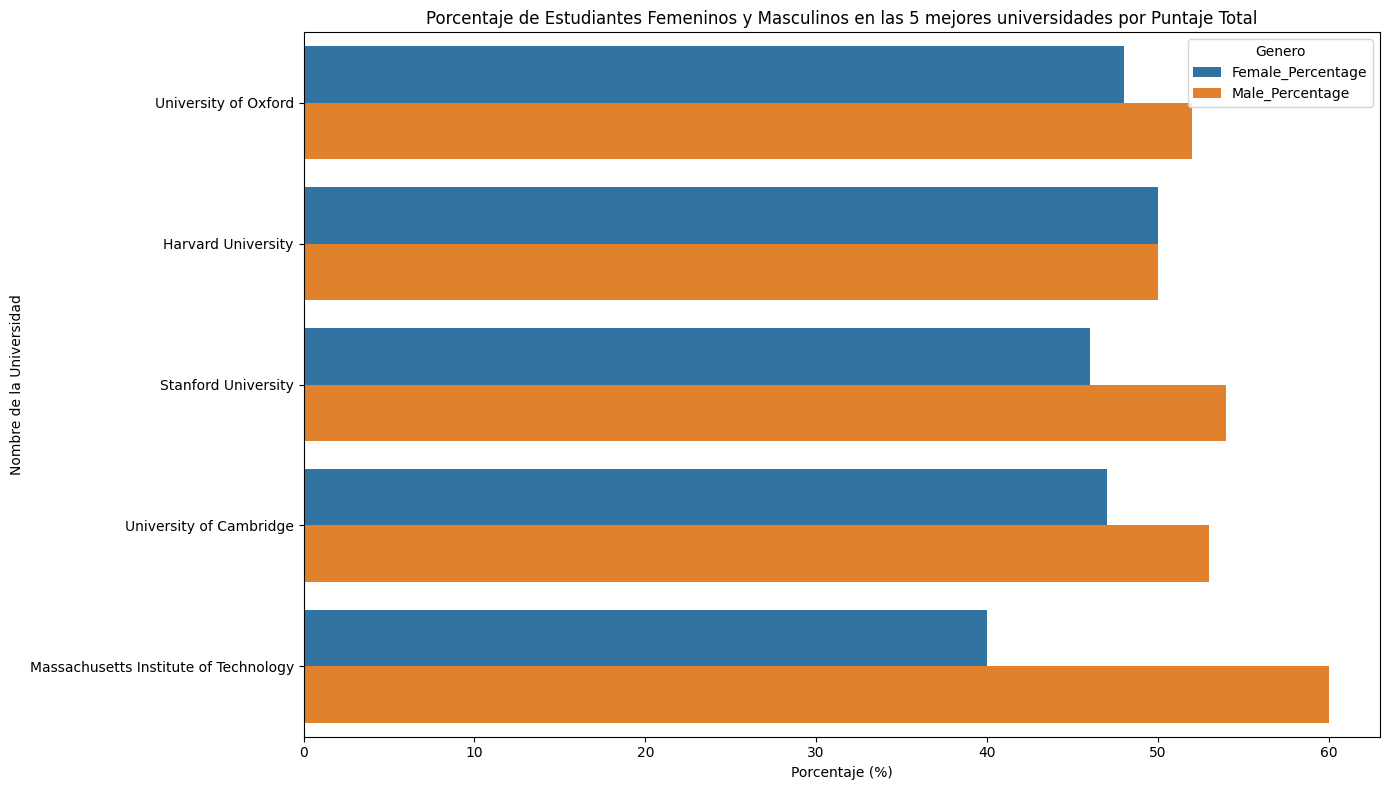

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

top_universities_df = df.sort_values(by='OverAll Score', ascending=False).head(5)

plot_df = top_universities_df[['Name of University', 'Female_Percentage', 'Male_Percentage']]
plot_df = plot_df.set_index('Name of University')

plot_df_melted = plot_df.melt(ignore_index=False, var_name='Gender', value_name='Percentage')
plot_df_melted = plot_df_melted.reset_index()

plot_df_melted['Percentage'] = pd.to_numeric(plot_df_melted['Percentage'], errors='coerce')

plt.figure(figsize=(14, 8))

sns.barplot(
    x='Percentage',
    y='Name of University',
    hue='Gender',
    data=plot_df_melted
)

plt.title('Porcentaje de Estudiantes Femeninos y Masculinos en las 5 mejores universidades por Puntaje Total')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Nombre de la Universidad')
plt.legend(title='Genero')
plt.tight_layout()
plt.show()

# Modelo de algoritmos predictivos o descriptivos.

## Bifurcación en el planteamiento del modelo

### Opción 1

In [19]:
df_model = df.dropna()

### Opción 2

In [20]:
df_model = df.fillna(df.mean(numeric_only=True))

In [21]:
df_model.isna().sum()

,0
University Rank,0
Name of University,0
Location,0
No of student,0
No of student per staff,0
International Student,0
OverAll Score,0
Teaching Score,0
Research Score,0
Citations Score,0


### Aplicación del modelo (según opción 1 u opción 2)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df_model[[
    'Teaching Score',
    'Research Score',
    'Citations Score',
    'Industry Income Score',
    'International Outlook Score',
    'International Student'
]]

y = df_model['OverAll Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5200
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.9921311650446226
MSE: 1.4865665361049158


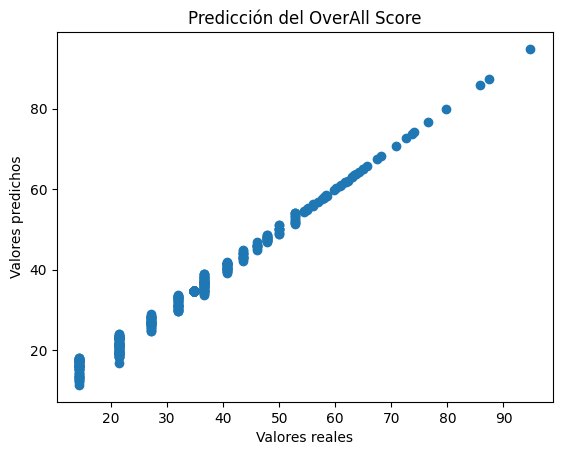

In [23]:
plt.scatter(y_test, y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Predicción del OverAll Score")
plt.show()

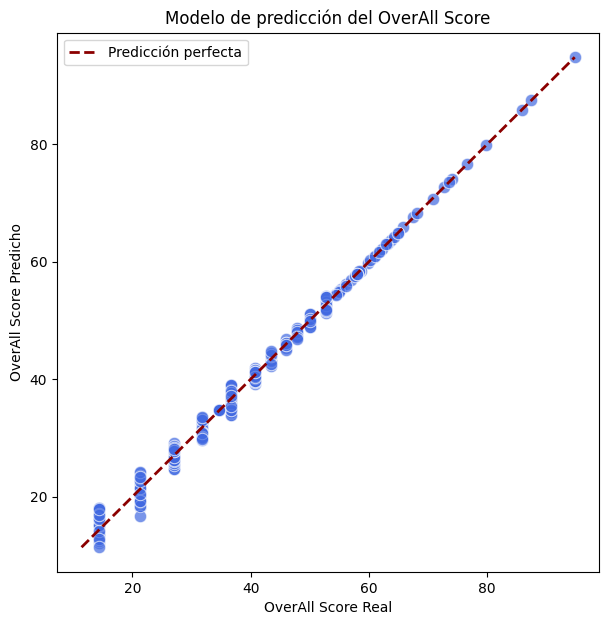

In [24]:
plt.figure(figsize=(7,7))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    color="royalblue",
    s=80,
    alpha=0.7
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Predicción perfecta"
)

plt.xlabel("OverAll Score Real")
plt.ylabel("OverAll Score Predicho")
plt.title("Modelo de predicción del OverAll Score")

plt.legend()

plt.show()
plt.show()

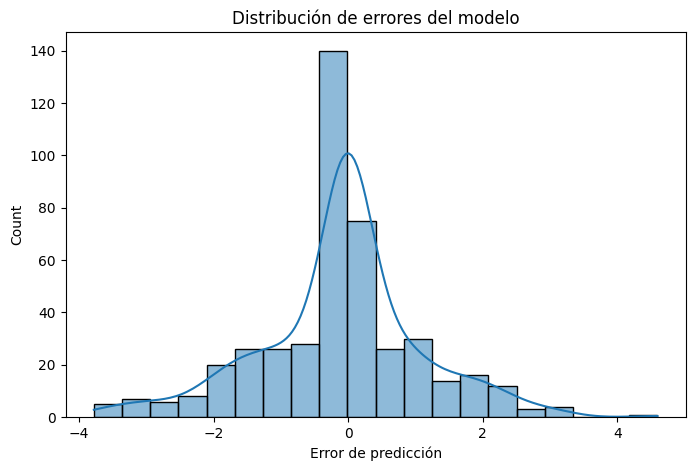

In [25]:
errores = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(errores, bins=20, kde=True)

plt.xlabel("Error de predicción")
plt.title("Distribución de errores del modelo")

plt.show()